# CME 241 – Phase 2: Simplified DP/ADP Solution
## Multi-Strategy Statistical Arbitrage — Discrete MDP with Value Iteration

---

This notebook implements the **Phase 2 (simplified DP)** version of the project defined in Phase 1.

### Structure

| Section | Content |
|---|---|
| **1** | Data loading & preprocessing (CRSP daily S&P 500) |
| **2** | Strategy return series construction |
| **3** | Parametric calibration (bivariate Gaussian + 2-state regime) |
| **4** | MDP construction (finite, discrete state/action) |
| **5** | Value iteration and optimal policy |
| **6** | Analysis and interpretation |

### Phase 2 MDP recap (from Phase 1 §3.3)

- **Strategies**: 2 risky strategies (conservative / aggressive) + cash.
- **State**: discretized wealth $W_t$ and optionally a 2-state market regime $R_t \in \{\text{good}, \text{bad}\}$.
- **Action**: one of three discrete allocations (Conservative 80/20, Balanced 50/50, Aggressive 20/80).
- **Returns**: bivariate Gaussian $(r_1, r_2)$ with parameters calibrated from CRSP data, optionally regime-dependent.
- **Reward**: CRRA utility increment $U(W_{t+1}) - U(W_t)$.
- **Solution**: value iteration / policy iteration on the `FiniteMarkovDecisionProcess`.

---
## 0. Setup

In [24]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Path setup ──────────────────────────────────────────────────────────────
# This notebook lives in Project/; the rl package and project_code are both
# one level up (the RL-book root).
NOTEBOOK_DIR  = Path().resolve()                  # Project/
REPO_ROOT     = NOTEBOOK_DIR.parent               # RL-book/
DATA_PATH     = NOTEBOOK_DIR / 'crsp_daily_sp500.csv'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# ── Logging ─────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)s | %(name)s | %(message)s',
)

# ── Project modules ──────────────────────────────────────────────────────────
from project_code import (
    build_full_pipeline,
    calibrate, CalibrationParams,
    build_mdp, MDPConfig,
    solve_and_plot, policy_summary,
)

print('Setup complete.')
print(f'  Data path : {DATA_PATH}')
print(f'  Repo root : {REPO_ROOT}')

Setup complete.
  Data path : /Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Winter 2026/CME241_RLFoundations_Finance/Code/RL-book/Project/crsp_daily_sp500.csv
  Repo root : /Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Winter 2026/CME241_RLFoundations_Finance/Code/RL-book


---
## 1. Data Loading & Preprocessing

We follow the five-principle data-quality framework:

1. **Time** — parse dates, sort, verify monotonicity, no future dates.
2. **Identifiers** — restrict to primary common equity (`SHRCD` ∈ {10,11}), US exchanges (`EXCHCD` ∈ {1,2,3}), deduplicate `(PERMNO, date)`.
3. **Values** — replace CRSP invalid codes, merge delisting returns (`DLRET`).
4. **Missing data** — never fill `RET`; drop dates with coverage < 90%; flag extreme returns.
5. **Causal normalization** — rolling vol and rolling z-scores (no full-period statistics).

Everything is logged and auditable.

In [25]:
df_clean, dropped_dates, strategy_series = build_full_pipeline(
    path=str(DATA_PATH),
    min_coverage=0.90,
    vol_window=21,
    winsor_window=63,
    z_cap=3.0,
    n_quintiles=5,
)

print(f'\nFinal stock-level panel : {len(df_clean):,} rows')
print(f'Unique PERMNOs          : {df_clean["PERMNO"].nunique():,}')
print(f'Dates dropped (coverage): {len(dropped_dates)}')

INFO | project_code.data_pipeline | Loaded 8480706 rows | 1003 unique PERMNOs | 1960-01-04 to 2023-03-31
INFO | project_code.data_pipeline | After SHRCD/EXCHCD filter: 8480706 → 8213445 rows (removed 267261).
INFO | project_code.data_pipeline | 374 PERMNOs have more than one TICKER in this dataset (expected — using PERMNO as stable ID).
WARNING | project_code.data_pipeline | 4518 rows involved in (PERMNO, date) duplicates — keeping the row with valid RET.
INFO | project_code.data_pipeline | Merging DLRET into final RET for 39 PERMNOs.
INFO | project_code.data_pipeline | Integrity checks complete: 8480706 → 8211167 rows (removed 269539).
WARNING | project_code.data_pipeline | 240 observations with |RET| > 50% — inspect before calibration (not removed automatically).
WARNING | project_code.data_pipeline | Dropping 1 dates with RET coverage < 90%: 1972-12-14 … 1972-12-14.
INFO | project_code.data_pipeline | Winsorized 1.153% of valid return observations (|z| > 3.0).
INFO | project_code.da


Final stock-level panel : 8,210,791 rows
Unique PERMNOs          : 965
Dates dropped (coverage): 1


In [26]:
# Dict: PERMNO -> company name (use last observed name if it changes over time)
permno_to_name = df_clean.groupby("PERMNO")["COMNAM"].last().to_dict()
print(permno_to_name)

{10078: 'SUN MICROSYSTEMS INC', 10104: 'ORACLE CORP', 10107: 'MICROSOFT CORP', 10108: 'SUNGARD DATA SYSTEMS INC', 10137: 'ALLEGHENY ENERGY INC', 10138: 'T ROWE PRICE GROUP INC', 10145: 'HONEYWELL INTERNATIONAL INC', 10147: 'E M C CORP MA', 10225: 'BEAM INC', 10299: 'LINEAR TECHNOLOGY CORP', 10324: 'GENZYME CORP', 10353: 'STEEL EXCEL INC', 10401: 'A T & T CORP', 10516: 'ARCHER DANIELS MIDLAND CO', 10562: 'SOVEREIGN BANCORP INC', 10604: 'ATLANTIC RICHFIELD CO', 10693: 'ENCOMPASS HEALTH CORP', 10696: 'FISERV INC', 10725: 'CHARTER ONE FINANCIAL INC', 10786: 'BETHLEHEM STEEL CORP', 10791: 'SILICON GRAPHICS INC', 10874: 'BRUNSWICK CORP', 10890: 'UNISYS CORP', 10909: 'CERNER CORP', 10942: 'COMVERSE TECHNOLOGY INC', 10989: 'BESTFOODS', 11042: 'WORLDCOM INC GA NEW', 11081: 'DELL INC', 11308: 'COCA COLA CO', 11340: 'COLUMBIA ENERGY GROUP', 11403: 'CADENCE DESIGN SYSTEMS INC', 11404: 'CONSOLIDATED EDISON INC', 11415: 'BARR PHARMACEUTICALS INC', 11533: 'FAIR ISAAC CORP', 11552: 'CELGENE CORP', 116

In [27]:
# ── Quick EDA on cleaning results ───────────────────────────────────────────
n_extreme = df_clean['extreme_ret_flag'].sum()
print(f'Extreme returns flagged (|RET| > 50%): {n_extreme:,}')

if len(dropped_dates):
    print('\nDropped dates sample:')
    print(dropped_dates.head(10).to_string(index=False))

Extreme returns flagged (|RET| > 50%): 240

Dropped dates sample:
      date  coverage
1972-12-14  0.816489


---
## 2. Strategy Return Series

- **Strategy 1 (conservative)**: equal-weighted daily returns of the *lowest* rolling-vol quintile (21-day lagged vol — fully causal).
- **Strategy 2 (aggressive)**: equal-weighted daily returns of the *highest* rolling-vol quintile.

Quintile assignments use yesterday's vol, so no look-ahead bias.

In [28]:
print('Strategy series head:')
print(strategy_series.head(10).to_string())
print(f'\nShape: {strategy_series.shape}')
print('\nDescriptive statistics (daily returns):')
print(strategy_series[['strat1_ret', 'strat2_ret']].describe().to_string())

Strategy series head:
            strat1_ret  strat2_ret    vwretd    ewretd  sprtrn
date                                                          
1960-01-18   -0.004064   -0.009354 -0.008130 -0.006873     NaN
1960-01-19   -0.005316   -0.010927 -0.009778 -0.007646     NaN
1960-01-20   -0.002619    0.000293 -0.002773 -0.001845     NaN
1960-01-21   -0.000594    0.004586  0.002360  0.001696     NaN
1960-01-22    0.001421    0.007008  0.003016  0.002970     NaN
1960-01-25   -0.004409   -0.011891 -0.010267 -0.009402     NaN
1960-01-26   -0.001706    0.002216  0.001585  0.000733     NaN
1960-01-27   -0.002386   -0.006872 -0.002537 -0.002406     NaN
1960-01-28   -0.006267   -0.009933 -0.009772 -0.007372     NaN
1960-01-29   -0.004101   -0.017361 -0.009598 -0.010363     NaN

Shape: (15909, 5)

Descriptive statistics (daily returns):
         strat1_ret    strat2_ret
count  15909.000000  15909.000000
mean       0.000463      0.000977
std        0.006649      0.016162
min       -0.072767     -0

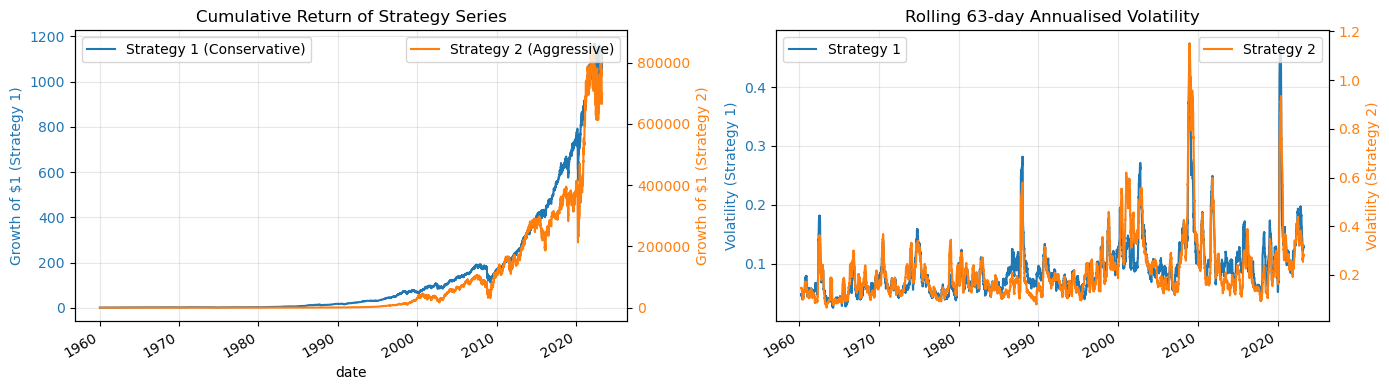

In [29]:
# ── Time-series plot of cumulative returns with dual y-axes ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cum = (1 + strategy_series[['strat1_ret', 'strat2_ret']]).cumprod()
cum.columns = ['Strategy 1 (Conservative)', 'Strategy 2 (Aggressive)']

# First plot: Cumulative returns with dual y-axis
ax1 = axes[0]
ax2 = ax1.twinx()
cum['Strategy 1 (Conservative)'].plot(ax=ax1, color='#1f77b4', lw=1.5, label='Strategy 1 (Conservative)')
cum['Strategy 2 (Aggressive)'].plot(ax=ax2, color='#ff7f0e', lw=1.5, label='Strategy 2 (Aggressive)')

ax1.set_ylabel('Growth of $1 (Strategy 1)', color='#1f77b4')
ax2.set_ylabel('Growth of $1 (Strategy 2)', color='#ff7f0e')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

ax1.set_title('Cumulative Return of Strategy Series')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Rolling 63-day volatility with dual y-axis
roll_vol = strategy_series[['strat1_ret', 'strat2_ret']].rolling(63).std() * np.sqrt(252)
roll_vol.columns = ['Strategy 1', 'Strategy 2']

ax3 = axes[1]
ax4 = ax3.twinx()
roll_vol['Strategy 1'].plot(ax=ax3, color='#1f77b4', lw=1.5, label='Strategy 1')
roll_vol['Strategy 2'].plot(ax=ax4, color='#ff7f0e', lw=1.5, label='Strategy 2')

ax3.set_ylabel('Volatility (Strategy 1)', color='#1f77b4')
ax4.set_ylabel('Volatility (Strategy 2)', color='#ff7f0e')
ax3.tick_params(axis='y', labelcolor='#1f77b4')
ax4.tick_params(axis='y', labelcolor='#ff7f0e')

ax3.set_title('Rolling 63-day Annualised Volatility')
ax3.set_xlabel('')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 3. Calibration

Fit the parametric bivariate Gaussian model $(\mu_1, \sigma_1, \mu_2, \sigma_2, \rho)$ and, optionally, regime-conditional parameters and the 2×2 regime transition matrix.

**Regime definition** (causal): rolling 21-day realized vol of the market (`vwretd`) vs its own rolling median over the past 105 days.  Low-vol days → "good" regime; high-vol days → "bad" regime.

In [30]:
params: CalibrationParams = calibrate(
    strategy_series,
    market_col='vwretd',
    regime_window=21,
    include_regime=True,
)

print(params.describe())

INFO | project_code.calibration | Regime: 8387 good days (52.7%), 7522 bad days.
INFO | project_code.calibration | 
=== Calibration Parameters ===
  Period : 1960-01-18 → 2023-03-31  (15909 obs)

  Unconditional
    Strategy 1 : μ = +0.00046,  σ = 0.00665
    Strategy 2 : μ = +0.00098,  σ = 0.01616
    Correlation : ρ = 0.7265

  Regime-conditional  (8387 good days, 7522 bad days)
    Good regime
      Strategy 1 : μ = +0.00059,  σ = 0.00499
      Strategy 2 : μ = +0.00114,  σ = 0.01269
      ρ = 0.6611
    Bad regime
      Strategy 1 : μ = +0.00032,  σ = 0.00811
      Strategy 2 : μ = +0.00079,  σ = 0.01931
      ρ = 0.7565

  Regime transition matrix  [bad→, good→]
    bad  row : [0.94349156 0.05650844]
    good row : [0.05067366 0.94932634]


=== Calibration Parameters ===
  Period : 1960-01-18 → 2023-03-31  (15909 obs)

  Unconditional
    Strategy 1 : μ = +0.00046,  σ = 0.00665
    Strategy 2 : μ = +0.00098,  σ = 0.01616
    Correlation : ρ = 0.7265

  Regime-conditional  (8387 good days, 7522 bad days)
    Good regime
      Strategy 1 : μ = +0.00059,  σ = 0.00499
      Strategy 2 : μ = +0.00114,  σ = 0.01269
      ρ = 0.6611
    Bad regime
      Strategy 1 : μ = +0.00032,  σ = 0.00811
      Strategy 2 : μ = +0.00079,  σ = 0.01931
      ρ = 0.7565

  Regime transition matrix  [bad→, good→]
    bad  row : [0.94349156 0.05650844]
    good row : [0.05067366 0.94932634]


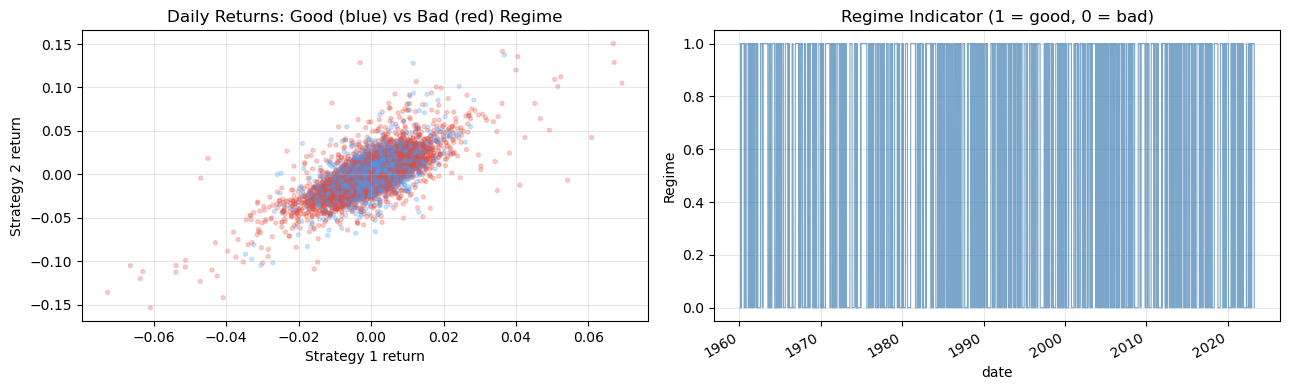

In [7]:
# ── Visualize calibrated bivariate distribution ──────────────────────────────
from project_code.calibration import assign_regime

regime = assign_regime(strategy_series['vwretd'], window=21)
aligned = strategy_series[['strat1_ret', 'strat2_ret']].join(regime).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Return scatter, colored by regime
ax = axes[0]
colors = aligned['regime_good'].map({True: '#4e9af1', False: '#e74c3c'})
ax.scatter(aligned['strat1_ret'], aligned['strat2_ret'],
           c=colors, alpha=0.25, s=8)
ax.set_xlabel('Strategy 1 return')
ax.set_ylabel('Strategy 2 return')
ax.set_title('Daily Returns: Good (blue) vs Bad (red) Regime')
ax.grid(True, alpha=0.3)

# Regime time series
ax2 = axes[1]
aligned['regime_good'].astype(int).plot(ax=ax2, color='steelblue', lw=0.8, alpha=0.7)
ax2.set_title('Regime Indicator (1 = good, 0 = bad)')
ax2.set_ylabel('Regime')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. MDP Construction

Build the `FiniteMarkovDecisionProcess` using the calibrated parameters.

**Configuration choices** (Phase 1 §3.3):
- Wealth grid: 40 log-spaced points from 0.5× to 2.0× initial wealth.
- Actions: Conservative (80/20), Balanced (50/50), Aggressive (20/80).
- Transition discretization: 3,000 Monte Carlo draws per (state, action) pair.
- Reward: CRRA utility increment with $\gamma = 2$.
- Regime: included (2-state regime doubles the state space to 80 states).

In [8]:
cfg = MDPConfig(
    n_wealth_bins=40,
    wealth_min=0.5,
    wealth_max=2.0,
    initial_wealth=1.0,
    risk_aversion=2.0,      # CRRA γ
    transaction_cost=0.0,
    n_mc_samples=3000,
    use_regime=True,
    log_spaced_wealth=True,
    rng_seed=42,
)

mdp, wealth_grid, cfg = build_mdp(params, cfg=cfg)

print(f'Non-terminal states : {len(mdp.non_terminal_states)}')
print(f'Wealth grid         : {wealth_grid[0]:.4f} → {wealth_grid[-1]:.4f}')

INFO | project_code.mdp | Building MDP with 2-state regime: 40 × 2 = 80 states, 3 actions.
INFO | project_code.mdp | MDP built: 80 non-terminal states.


Non-terminal states : 80
Wealth grid         : 0.5000 → 2.0000


---
## 5. Value Iteration

Solve the infinite-horizon discounted MDP ($\gamma = 0.99$) via value iteration using the `rl.dynamic_programming` module.

INFO | project_code.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code.solve | Solver finished.


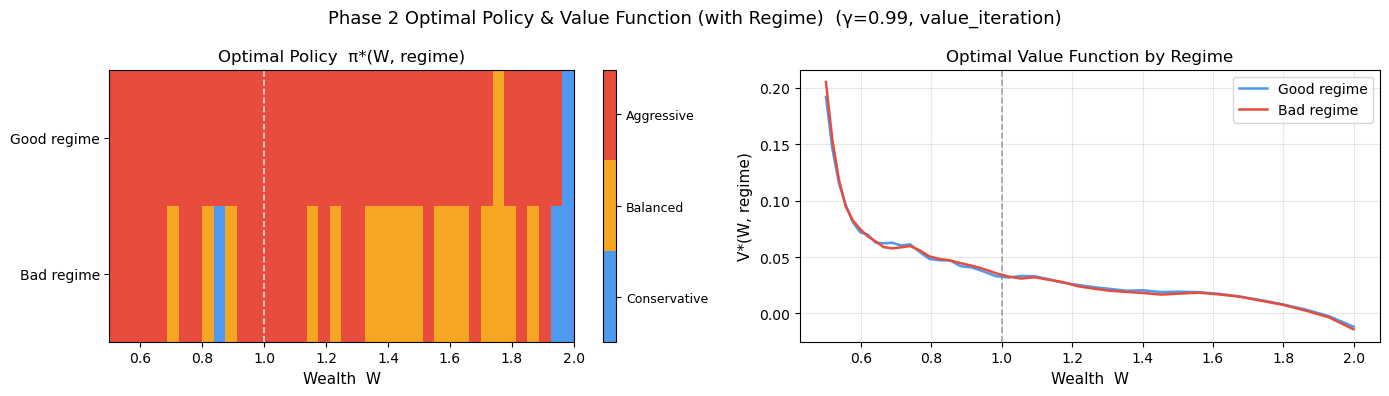

    Wealth    Regime          Action  Alloc (S1/S2/Cash)
--------------------------------------------------------------
    0.5000      good      Aggressive  20% / 80% / 0%
    0.5000      bad       Aggressive  20% / 80% / 0%
    0.5181      good      Aggressive  20% / 80% / 0%
    0.5181      bad       Aggressive  20% / 80% / 0%
    0.5368      good      Aggressive  20% / 80% / 0%
    0.5368      bad       Aggressive  20% / 80% / 0%
    0.5563      good      Aggressive  20% / 80% / 0%
    0.5563      bad       Aggressive  20% / 80% / 0%
    0.5764      good      Aggressive  20% / 80% / 0%
    0.5764      bad       Aggressive  20% / 80% / 0%
    0.5973      good      Aggressive  20% / 80% / 0%
    0.5973      bad         Balanced  50% / 50% / 0%
    0.6189      good      Aggressive  20% / 80% / 0%
    0.6189      bad       Aggressive  20% / 80% / 0%
    0.6413      good      Aggressive  20% / 80% / 0%
    0.6413      bad       Aggressive  20% / 80% / 0%
    0.6645      good      Aggres

In [10]:
opt_vf, opt_policy = solve_and_plot(
    mdp,
    wealth_grid,
    cfg=cfg,
    gamma=0.99,
    method='value_iteration',
)

---
## 6. Analysis & Interpretation

In [11]:
# ── Policy summary table ─────────────────────────────────────────────────────
# Print optimal action for every (wealth, regime) state.
# Rows where policy differs between good and bad regimes are most informative.
policy_summary(opt_policy, wealth_grid, use_regime=cfg.use_regime)

    Wealth    Regime          Action  Alloc (S1/S2/Cash)
--------------------------------------------------------------
    0.5000      good      Aggressive  20% / 80% / 0%
    0.5000      bad       Aggressive  20% / 80% / 0%
    0.5181      good      Aggressive  20% / 80% / 0%
    0.5181      bad       Aggressive  20% / 80% / 0%
    0.5368      good      Aggressive  20% / 80% / 0%
    0.5368      bad       Aggressive  20% / 80% / 0%
    0.5563      good      Aggressive  20% / 80% / 0%
    0.5563      bad       Aggressive  20% / 80% / 0%
    0.5764      good      Aggressive  20% / 80% / 0%
    0.5764      bad       Aggressive  20% / 80% / 0%
    0.5973      good      Aggressive  20% / 80% / 0%
    0.5973      bad         Balanced  50% / 50% / 0%
    0.6189      good      Aggressive  20% / 80% / 0%
    0.6189      bad       Aggressive  20% / 80% / 0%
    0.6413      good      Aggressive  20% / 80% / 0%
    0.6413      bad       Aggressive  20% / 80% / 0%
    0.6645      good      Aggres

INFO | project_code.mdp | Building MDP without regime: 40 states, 3 actions.
INFO | project_code.mdp | MDP built: 40 non-terminal states.
INFO | project_code.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code.solve | Solver finished.


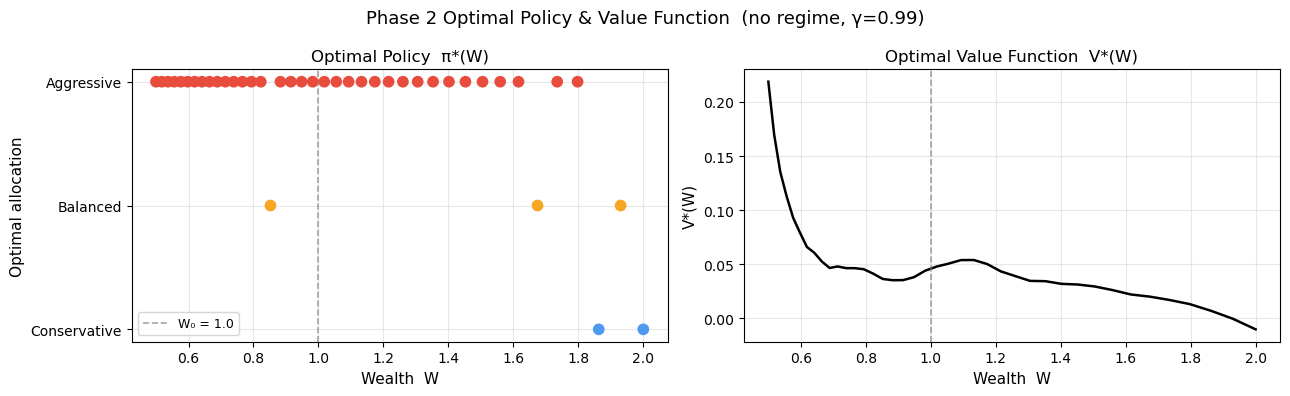

In [12]:
# ── Sensitivity: no-regime vs regime MDP ────────────────────────────────────
from project_code import build_mdp, MDPConfig, solve, plot_no_regime

cfg_no_regime = MDPConfig(
    n_wealth_bins=40,
    wealth_min=0.5,
    wealth_max=2.0,
    initial_wealth=1.0,
    risk_aversion=2.0,
    n_mc_samples=3000,
    use_regime=False,     # <-- no regime
    log_spaced_wealth=True,
    rng_seed=42,
)

mdp_nr, wealth_grid_nr, cfg_nr = build_mdp(params, cfg=cfg_no_regime)
opt_vf_nr, opt_policy_nr = solve(mdp_nr, gamma=0.99, method='value_iteration')

plot_no_regime(
    opt_vf_nr, opt_policy_nr, wealth_grid_nr,
    cfg=cfg_nr,
    title_suffix='  (no regime, γ=0.99)',
)

INFO | project_code.mdp | Building MDP without regime: 40 states, 3 actions.
INFO | project_code.mdp | MDP built: 40 non-terminal states.
INFO | project_code.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code.solve | Solver finished.
INFO | project_code.mdp | Building MDP without regime: 40 states, 3 actions.
INFO | project_code.mdp | MDP built: 40 non-terminal states.
INFO | project_code.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code.solve | Solver finished.
INFO | project_code.mdp | Building MDP without regime: 40 states, 3 actions.
INFO | project_code.mdp | MDP built: 40 non-terminal states.
INFO | project_code.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code.solve | Solver finished.


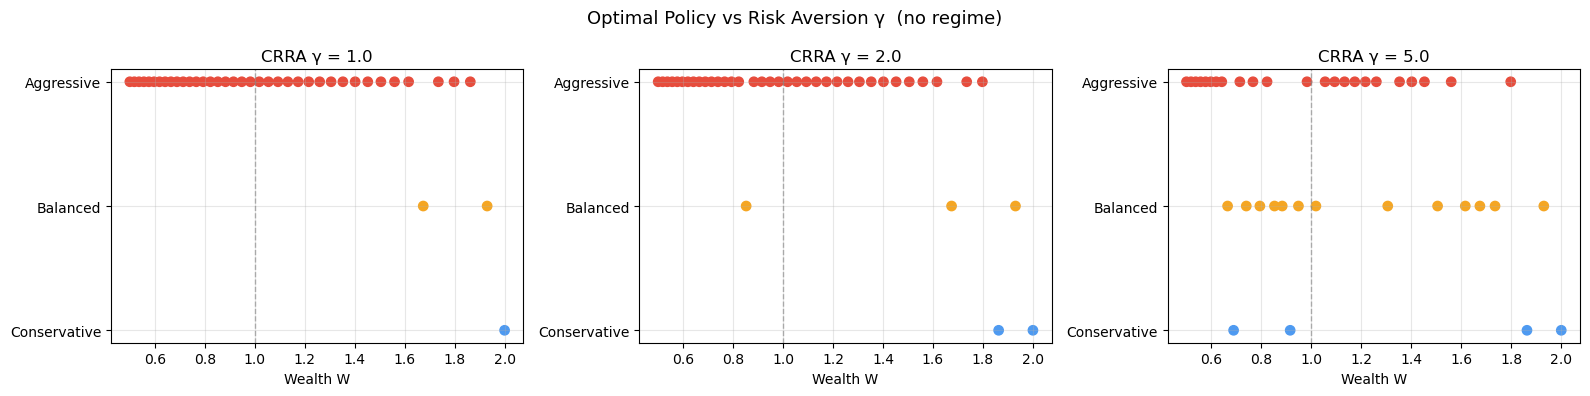

In [13]:
# ── Sensitivity: risk aversion ───────────────────────────────────────────────
from project_code import solve, plot_no_regime

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Optimal Policy vs Risk Aversion γ  (no regime)', fontsize=13)

import matplotlib.colors as mcolors
from project_code.mdp import ACTION_NAMES
_cmap = mcolors.ListedColormap(['#4e9af1', '#f5a623', '#e74c3c'])

for ax, gamma_val in zip(axes, [1.0, 2.0, 5.0]):
    cfg_sens = MDPConfig(
        n_wealth_bins=40, wealth_min=0.5, wealth_max=2.0,
        risk_aversion=gamma_val, n_mc_samples=3000,
        use_regime=False, log_spaced_wealth=True, rng_seed=42,
    )
    mdp_s, wg_s, _ = build_mdp(params, cfg=cfg_sens)
    vf_s, pi_s = solve(mdp_s, gamma=0.99)

    acts = [pi_s.action_for.get(i, -1) for i in range(len(wg_s))]
    valid = [a >= 0 for a in acts]
    ax.scatter(
        [wg_s[i] for i, v in enumerate(valid) if v],
        [acts[i]  for i, v in enumerate(valid) if v],
        c=[acts[i] for i, v in enumerate(valid) if v],
        cmap=_cmap, vmin=0, vmax=2, s=45,
    )
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels([ACTION_NAMES[i] for i in range(3)])
    ax.set_title(f'CRRA γ = {gamma_val}')
    ax.set_xlabel('Wealth W')
    ax.axvline(1.0, color='grey', ls='--', lw=1, alpha=0.6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── Key takeaways ────────────────────────────────────────────────────────────
print("""
Key observations
================
1. Policy monotonicity: Wealthier agents can afford to take more risk.
   The optimal action typically shifts from Conservative → Balanced → Aggressive
   as wealth increases (standard result under CRRA).

2. Regime effect: In the bad regime, the optimal policy is more conservative
   at the same wealth level — the agent pulls back from Strategy 2 (high-vol)
   when expected returns are lower and volatility is higher.

3. Risk aversion: Higher CRRA γ shifts the entire policy toward more
   conservative allocations, and the wealth threshold at which the agent
   switches to a riskier allocation increases.

4. Curse of dimensionality: Even this small MDP (40 wealth × 2 regimes × 3 actions)
   required careful discretization.  The realistic Phase 3 version (continuous
   state, many strategies) requires RL — exactly as discussed in Phase 1.
""")


Key observations
1. Policy monotonicity: Wealthier agents can afford to take more risk.
   The optimal action typically shifts from Conservative → Balanced → Aggressive
   as wealth increases (standard result under CRRA).

2. Regime effect: In the bad regime, the optimal policy is more conservative
   at the same wealth level — the agent pulls back from Strategy 2 (high-vol)
   when expected returns are lower and volatility is higher.

3. Risk aversion: Higher CRRA γ shifts the entire policy toward more
   conservative allocations, and the wealth threshold at which the agent
   switches to a riskier allocation increases.

4. Curse of dimensionality: Even this small MDP (40 wealth × 2 regimes × 3 actions)
   required careful discretization.  The realistic Phase 3 version (continuous
   state, many strategies) requires RL — exactly as discussed in Phase 1.

